In [4]:
import sys
import torch
import torchvision

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Apple GPU available:", torch.backends.mps.is_available())

Python: /Users/fahad/Downloads/To keep/2026/09 Sep/AR_VR/assignmemt_1/first-light-pytorch/.venv/bin/python
PyTorch: 2.14.0
Torchvision: 0.29.0
Apple GPU available: True


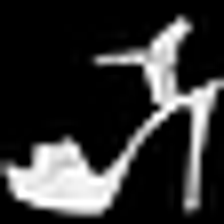

Label number: 5
Category: Sandal


In [7]:
from torchvision.datasets import FashionMNIST

training_data = FashionMNIST(
    root="data",
    train=True,
    download=True

)

image, label = training_data[9]

display(image.resize((224, 224)))
print("Label number:", label)
print("Category:", training_data.classes[label])

In [8]:
from torchvision.transforms import ToTensor

to_tensor = ToTensor()
pixels = to_tensor(image)

print("Shape:", pixels.shape)
print("Data type:", pixels.dtype)
print("Lowest brightness:", pixels.min().item())
print("Highest brightness:", pixels.max().item())

Shape: torch.Size([1, 28, 28])
Data type: torch.float32
Lowest brightness: 0.0
Highest brightness: 1.0


In [9]:
from torch import nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

scores = model(pixels.unsqueeze(0))

print("Output shape:", scores.shape)
print("Scores:", scores)

Output shape: torch.Size([1, 10])
Scores: tensor([[ 0.0705,  0.0571, -0.1318,  0.1692,  0.1237, -0.0038,  0.1324,  0.2291,
         -0.0316,  0.0041]], grad_fn=<AddmmBackward0>)


In [10]:
predicted_label = scores.argmax(dim=1).item()

print("Predicted:", training_data.classes[predicted_label])
print("Actual:", training_data.classes[label])

loss_fn = nn.CrossEntropyLoss()
target = torch.tensor([label], dtype=torch.long)
loss = loss_fn(scores, target)

print("Loss:", loss.item())

Predicted: Sneaker
Actual: Sandal
Loss: 2.3733835220336914


In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

optimizer.zero_grad()

before_scores = model(pixels.unsqueeze(0))
before_loss = loss_fn(before_scores, target)

# calculate gradients
before_loss.backward()
# update the model's parameters
optimizer.step()

with torch.no_grad():
    after_scores = model(pixels.unsqueeze(0))
    after_loss = loss_fn(after_scores, target)

print("Loss before:", before_loss.item())
print("Loss after:", after_loss.item())

Loss before: 2.3733835220336914
Loss after: 2.2519853115081787


In [15]:
from torch.utils.data import DataLoader

train_dataset = FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset = FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [16]:
train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False
)

images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([64, 1, 28, 28])
Labels: torch.Size([64])


In [17]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
print("Training on:", device)

Training on: mps


In [19]:
loss_history = []

for epoch in range(3):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        batch_scores = model(images)
        batch_loss = loss_fn(batch_scores, labels)

        # calculate gradients from batch_loss : still, verify if I wrote correctly. 
        batch_loss.backward()
        # update the model's parameters : still, verify if I wrote correctly.
        optimizer.step()

        total_loss += batch_loss.item() * images.size(0)

    epoch_loss = total_loss / len(train_dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch + 1}: loss = {epoch_loss:.4f}")

Epoch 1: loss = 1.1799
Epoch 2: loss = 0.6811
Epoch 3: loss = 0.5822


In [21]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        scores = model(images)
        predictions = scores.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = (correct/total)*100
print(f"Test accuracy: {test_accuracy:.2f}%")

Test accuracy: 79.41%


Matplotlib is building the font cache; this may take a moment.


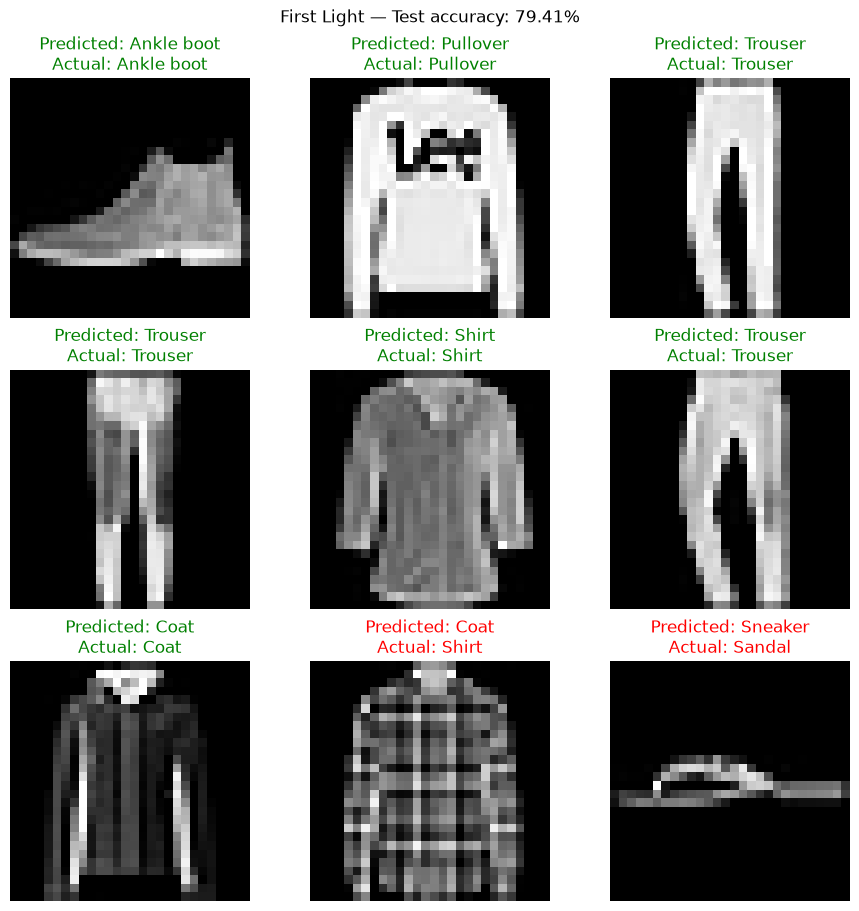

In [22]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

model.eval()
with torch.no_grad():
    predictions = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(
    3, 3, figsize=(9, 9), layout="constrained"
)

for i, ax in enumerate(axes.flat):
    predicted_id = predictions[i].item()
    actual_id = labels[i].item()

    predicted_name = test_dataset.classes[predicted_id]
    actual_name = test_dataset.classes[actual_id]
    color = "green" if predicted_id == actual_id else "red"

    ax.imshow(images[i].squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"Predicted: {predicted_name}\nActual: {actual_name}",
        color=color
    )
    ax.axis("off")

fig.suptitle(f"First Light — Test accuracy: {test_accuracy:.2f}%")
fig.savefig("prediction_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
for epoch in range(3, 6):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        batch_scores = model(images)
        batch_loss = loss_fn(batch_scores, labels)

        # calculate gradients from batch_loss : still, verify if I wrote correctly. 
        batch_loss.backward()
        # update the model's parameters : still, verify if I wrote correctly.
        optimizer.step()

        total_loss += batch_loss.item() * images.size(0)

    epoch_loss = total_loss / len(train_dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch + 1}: loss = {epoch_loss:.4f}")

Epoch 4: loss = 0.5336
Epoch 5: loss = 0.5041
Epoch 6: loss = 0.4844


In [24]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        scores = model(images)
        predictions = scores.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = (correct/total)*100
print(f"Test accuracy: {test_accuracy:.2f}%")

Test accuracy: 82.37%


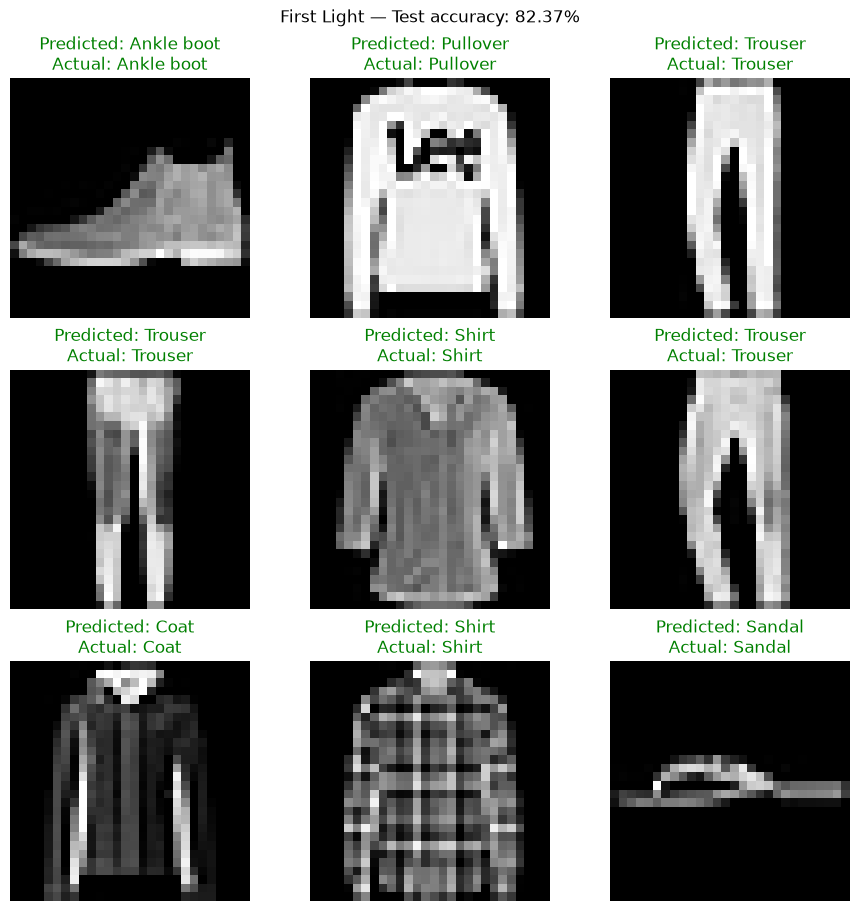

In [25]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

model.eval()
with torch.no_grad():
    predictions = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(
    3, 3, figsize=(9, 9), layout="constrained"
)

for i, ax in enumerate(axes.flat):
    predicted_id = predictions[i].item()
    actual_id = labels[i].item()

    predicted_name = test_dataset.classes[predicted_id]
    actual_name = test_dataset.classes[actual_id]
    color = "green" if predicted_id == actual_id else "red"

    ax.imshow(images[i].squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"Predicted: {predicted_name}\nActual: {actual_name}",
        color=color
    )
    ax.axis("off")

fig.suptitle(f"First Light — Test accuracy: {test_accuracy:.2f}%")
fig.savefig("prediction_gallery.png", dpi=150, bbox_inches="tight")
plt.show()